# Engenharia de atributos

A [análise exploratória](01_exploratory_data_analysis.ipynb) revelou diversos atributos fortemente associados à sobrevivência dos passageiros, assim como grupos de variáveis que capturam aspectos relacionados à identidade do passageiro, status socioeconômico e contexto da viagem. Neste notebook, utilizamos essas observações para construir novos atributos que podem melhorar a capacidade dos modelos de aprendizado de máquina em capturar padrões relevantes nos dados.

Engenharia de atributos é o processo de transformar variáveis existentes em novas representações que reflitam melhor a estrutura subjacente do problema. Ao extrair informações de atributos brutos, combinar variáveis relacionadas e criar indicadores mais significativos, podemos frequentemente fornecer aos modelos uma visão mais informativa dos dados do que aquela disponível apenas com os atributos originais.

Os atributos introduzidos neste notebook são motivados pelos padrões observados durante a análise exploratória dos dados. De forma geral, a sobrevivência no Titanic parece ter sido influenciada por fatores como classe do passageiro, sexo, idade, estrutura familiar e status social. Os atributos construídos a seguir têm como objetivo tornar esses fatores mais explícitos e facilitar seu aprendizado pelos modelos de aprendizado de máquina.

## Importações e carregamento dos dados

Antes de criar novos atributos, carregamos o conjunto de dados processado gerado no notebook anterior. Esse conjunto já inclui o tratamento de valores faltantes, a limpeza dos atributos e as transformações identificadas durante a etapa de análise exploratória.

Em seguida, importamos as bibliotecas necessárias para a engenharia de atributos e para as etapas posteriores de pré-processamento.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

sns.set_theme()

# Load data processed and saved in the EDA notebook
df_full = pd.read_parquet(
    "../data/processed/01_data.parquet"
)
df_features = pd.read_parquet(
    "../data/processed/01_features.parquet"
)

In [2]:
df_full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,IsTrainSet
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True


In [3]:
df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


## Registro de atributos

Ao longo deste notebook, mantemos um registro de atributos (`df_features`) que descreve cada variável presente no conjunto de dados. Além de documentar o nome do atributo, seu tipo, origem e descrição, introduzimos um novo campo chamado `UsedInModel`.

Esse campo indica se um atributo será incluído diretamente na matriz final de dados utilizada para o treinamento dos modelos. Neste estágio, todos os atributos são inicializados com o valor `False`. À medida que novos atributos são criados e atributos existentes são transformados ou codificados, esse registro será atualizado de acordo.

A manutenção desse registro fornece uma visão clara do pipeline de engenharia de atributos e ajuda a acompanhar a origem e o propósito de cada variável criada ao longo do projeto.


In [4]:
# Initialize the feature registry
df_features["UsedInModel"] = False

## Atributos construídos

Nesta seção, criamos novos atributos a partir da extração ou combinação de informações presentes nas variáveis existentes.


### `Title` (a partir de `Name`)

Durante a análise exploratória dos dados, observamos que os nomes dos passageiros contêm informações valiosas além de uma simples identificação. Em particular, títulos de tratamento como `Mr.`, `Mrs.`, `Miss` e `Master` apresentaram taxas de sobrevivência significativamente diferentes, sugerindo que eles capturam características demográficas e sociais relevantes para a tarefa de previsão.

Em vez de utilizar o campo completo `Name`, que possui uma cardinalidade muito alta e é inadequado para a maioria dos algoritmos de aprendizado de máquina, extraímos apenas o título do passageiro. Essa transformação preserva a parte informativa do atributo, ao mesmo tempo em que produz uma variável categórica compacta que pode ser facilmente codificada para a modelagem.

Os títulos dos passageiros seguem um padrão consistente no conjunto de dados, aparecendo entre o sobrenome e o nome próprio. Dessa forma, podemos extraí-los de maneira eficiente utilizando uma expressão regular, assim como já fizemos na [EDA](01_exploratory_data_analysis.ipynb).


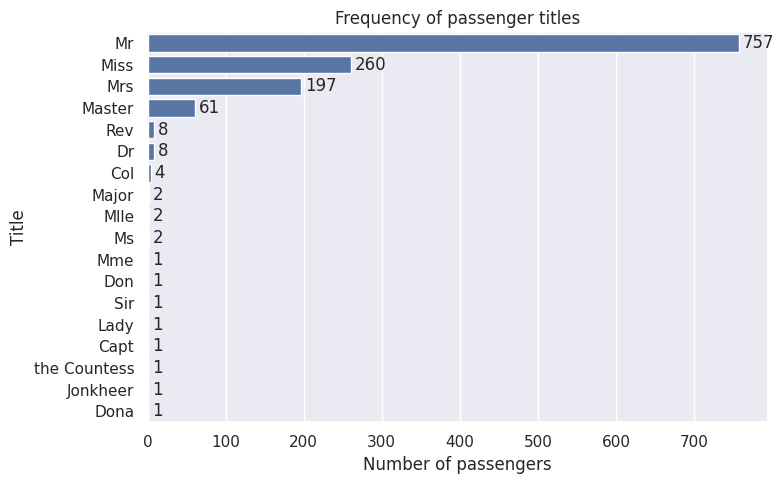

In [5]:
df_full["Title"] = df_full["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)

title_counts = (
    df_full["Title"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=title_counts.values,
    y=title_counts.index,
)

plt.title("Frequency of passenger titles")
plt.xlabel("Number of passengers")
plt.ylabel("Title")

for i, count in enumerate(title_counts.values):
    ax.text(
        count + 5,
        i,
        str(count),
        va="center"
    )

plt.tight_layout()
plt.show()


Assim como todos os atributos criados ao longo deste notebook, a nova variável construída `Title` é adicionada ao registro de atributos (`df_features`). Manter esse registro atualizado documenta a origem, o tipo e o uso pretendido de cada atributo, tornando o pipeline de engenharia de atributos mais fácil de compreender e reproduzir.


In [6]:
df_features.loc[len(df_features)] = {
    "Name": "Title",
    "Type": "categorical",
    "Category": "extracted",
    "Source": "Name",
    "UsedInModel": False,
    "Description": "Honorific title extracted from the passenger's name."
}

### `TitleGrouped` (a partir de `Title`)

Os títulos extraídos incluem algumas categorias comuns juntamente com várias categorias raras. Alguns desses títulos menos frequentes apresentam taxas de sobrevivência extremas simplesmente porque aparecem apenas uma ou duas vezes no conjunto de dados. Por exemplo, o título `Capt.` apresenta uma taxa de sobrevivência de 0%, mas essa "categoria" corresponde a apenas um passageiro: o Capitão Edward Smith, que faleceu durante o naufrágio do navio. Embora esse seja um detalhe histórico interessante, ele fornece pouca evidência estatística útil para um modelo de aprendizado de máquina.

Para reduzir o impacto dessas categorias com poucas observações, agrupamos os títulos menos frequentes em uma única categoria `Rare`. Essa transformação preserva a distinção entre títulos comuns e incomuns, ao mesmo tempo em que fornece ao modelo uma representação mais robusta e generalizável dos dados.


In [7]:
# Keep the most common titles and group the remaining ones as "Rare"
common_titles = ["Mr", "Miss", "Mrs", "Master"]

df_full["TitleGrouped"] = (
    df_full["Title"]
    .where(df_full["Title"].isin(common_titles), "Rare")
)

Após agrupar as categorias menos frequentes, o atributo resultante `TitleGrouped` contém um pequeno número de categorias bem representadas, mantendo ao mesmo tempo as informações demográficas identificadas durante a análise exploratória. Essa representação é consideravelmente mais adequada para modelos de aprendizado de máquina do que o atributo original `Title`.


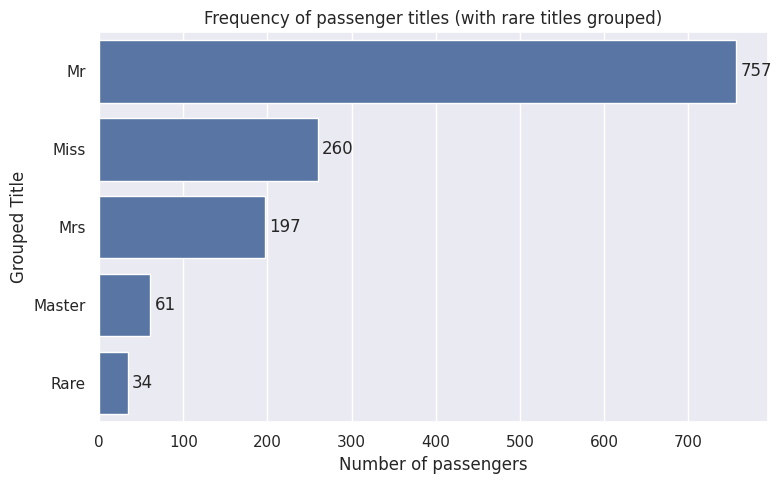

In [8]:
title_counts = (
    df_full["TitleGrouped"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=title_counts.values,
    y=title_counts.index,
)

plt.title("Frequency of passenger titles (with rare titles grouped)")
plt.xlabel("Number of passengers")
plt.ylabel("Grouped Title")

for i, count in enumerate(title_counts.values):
    ax.text(
        count + 5,
        i,
        str(count),
        va="center"
    )

plt.tight_layout()
plt.show()

A figura acima mostra a distribuição dos títulos agrupados. Comparada ao atributo original, a nova representação contém apenas algumas categorias bem preenchidas juntamente com uma única categoria `Rare`, tornando-a mais adequada para modelos de aprendizado de máquina, ao mesmo tempo em que preserva a distinção entre títulos comuns e incomuns dos passageiros.

Como anteriormente, também registramos o novo atributo em `df_features` para documentar sua origem e uso pretendido ao longo das demais etapas do projeto.


In [9]:
df_features.loc[len(df_features)] = {
    "Name": "TitleGrouped",
    "Type": "categorical",
    "Category": "engineered",
    "Source": "Title",
    "UsedInModel": False,
    "Description": "Passenger title with infrequent categories grouped into 'Rare'."
}

### `FamilySize` (a partir de `SibSp` e `Parch`)

Durante a análise exploratória, observamos que tanto `SibSp` quanto `Parch` apresentam uma relação com a sobrevivência dos passageiros. Em vez de tratar essas variáveis de forma independente, combinamos ambas em um único atributo que representa o número total de familiares viajando juntos.

O novo atributo, `FamilySize`, é definido como o número de irmãos/cônjuges (`SibSp`) somado ao número de pais/filhos (`Parch`), mais um para incluir o próprio passageiro. Isso fornece uma medida mais intuitiva do tamanho do grupo de viagem de cada passageiro.


In [10]:
# Create the feature.
df_full["FamilySize"] = (
    df_full["SibSp"] +
    df_full["Parch"] +
    1
)

# Add new feature to df_features.
df_features.loc[len(df_features)] = {
    "Name": "FamilySize",
    "Type": "numerical",
    "Category": "engineered",
    "Source": "SibSp, Parch",
    "UsedInModel": False,
    "Description": "Total number of family members aboard, including the passenger."
}

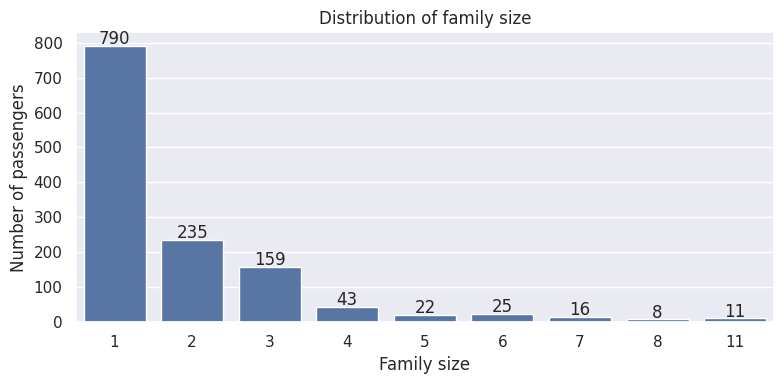

In [11]:
plt.figure(figsize=(8, 4))

ax = sns.countplot(
    data=df_full,
    x="FamilySize"
)

plt.title("Distribution of family size")
plt.xlabel("Family size")
plt.ylabel("Number of passengers")

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 5,
        f"{int(p.get_height())}",
        ha="center"
    )

plt.tight_layout()
plt.show()

A distribuição mostra que a maioria dos passageiros viajava sozinha ou com um pequeno número de familiares, enquanto grupos familiares grandes eram relativamente raros. Esse atributo construído fornece uma representação mais compacta da estrutura familiar do que as variáveis originais `SibSp` e `Parch` e pode ajudar os modelos de aprendizado de máquina a capturar padrões associados ao tamanho do grupo de viagem.

Embora `FamilySize` tenha sido criado para representar o tamanho geral do grupo de viagem de um passageiro, não é imediatamente claro se esse atributo apresenta uma relação monotônica ou mesmo consistente com a sobrevivência. Famílias pequenas podem ter se beneficiado de uma evacuação coordenada, enquanto grupos maiores podem ter enfrentado dificuldades adicionais de coordenação. Passageiros viajando sozinhos também podem apresentar um comportamento de sobrevivência distinto daqueles viajando com familiares.

Para compreender melhor essa relação, calculamos a taxa de sobrevivência em função de `FamilySize` e comparamos os resultados entre diferentes tamanhos de grupos.


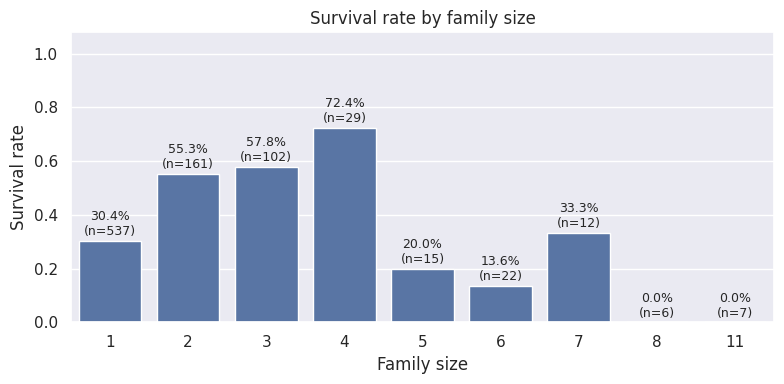

In [12]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

family_survival = (
    df_plot
    .groupby("FamilySize", as_index=False)
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "size")
    )
    .sort_values("FamilySize")
)

# IMPORTANT: force categorical order
family_survival["FamilySize"] = family_survival["FamilySize"].astype(str)
order = family_survival["FamilySize"].tolist()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=family_survival,
    x="FamilySize",
    y="SurvivalRate",
    order=order
)

plt.title("Survival rate by family size")
plt.xlabel("Family size")
plt.ylabel("Survival rate")

for i, row in family_survival.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 0.01,
        f'{row["SurvivalRate"]:.1%}\n(n={row["Count"]})',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

Os resultados sugerem que `FamilySize` está de fato associado à sobrevivência, mas essa relação não é linear. Passageiros viajando em grupos pequenos tendem a apresentar taxas de sobrevivência mais elevadas, enquanto aqueles viajando sozinhos ou em famílias muito grandes apresentam menores probabilidades de sobrevivência.

Esse padrão indica que `FamilySize` captura efeitos comportamentais e logísticos relevantes durante a evacuação, além das informações codificadas individualmente por `SibSp` e `Parch`. No entanto, a variabilidade observada entre diferentes tamanhos de grupos também sugere que esse atributo deve ser interpretado em conjunto com outras características dos passageiros, em vez de ser analisado isoladamente.


### `IsAlone` (a partir de `FamilySize`)

A análise anterior mostrou que `FamilySize` está associado à sobrevivência de forma não linear. Em particular, passageiros viajando sozinhos e aqueles pertencentes a famílias muito grandes tendem a apresentar taxas de sobrevivência menores em comparação com passageiros viajando em pequenos grupos familiares.

Isso sugere que a *presença ou ausência de acompanhantes*, em vez do tamanho exato do grupo, pode ser um sinal mais informativo para a previsão. Para capturar esse efeito de forma mais direta, derivamos um atributo binário indicando se o passageiro estava viajando sozinho.


In [13]:
# Create feature
df_full["IsAlone"] = (df_full["FamilySize"] == 1).astype(int)

# Add new feature to df_features
df_features.loc[len(df_features)] = {
    "Name": "IsAlone",
    "Type": "indicator",
    "Category": "engineered",
    "Source": "FamilySize",
    "UsedInModel": False,
    "Description": "Binary indicator of whether the passenger was traveling alone (1) or not (0)."
}

O atributo `FamilySize` sugeriu que passageiros viajando sozinhos apresentam um comportamento de sobrevivência distinto em comparação com aqueles viajando com familiares. No entanto, esse efeito pode ser explicado principalmente pela distinção binária entre viajar sozinho ou acompanhado, em vez do número exato de familiares a bordo.

Para investigar essa hipótese de forma mais direta, definimos um atributo indicador binário, `IsAlone`, e analisamos como as taxas de sobrevivência diferem entre esses dois grupos.


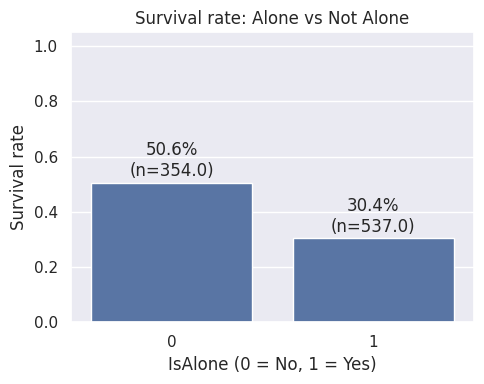

In [14]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

isalone_survival = (
    df_plot
    .groupby("IsAlone")["Survived"]
    .agg(SurvivalRate="mean", Count="size")
    .reset_index()
)

plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=isalone_survival,
    x="IsAlone",
    y="SurvivalRate"
)

plt.title("Survival rate: Alone vs Not Alone")
plt.xlabel("IsAlone (0 = No, 1 = Yes)")
plt.ylabel("Survival rate")

for _, row in isalone_survival.iterrows():
    ax.text(
        row["IsAlone"],
        row["SurvivalRate"] + 0.01,
        f'{row["SurvivalRate"]:.1%}\n(n={row["Count"]})',
        ha="center",
        va="bottom"
    )

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

O gráfico destaca uma diferença clara nas taxas de sobrevivência entre passageiros viajando sozinhos e aqueles viajando com familiares. Passageiros que estavam sozinhos apresentam uma menor probabilidade de sobrevivência em comparação com aqueles acompanhados por pelo menos um familiar.

Esse resultado reforça a ideia de que a organização social dos passageiros teve um papel importante durante a evacuação. A representação binária `IsAlone` captura esse efeito de forma mais direta e interpretável do que a variável original `FamilySize`, tornando-a um atributo promissor para as etapas posteriores de modelagem.


### `TicketGroupSize` (a partir de `Ticket`)

Embora o atributo `Ticket` pareça ser apenas um identificador, a inspeção do conjunto de dados sugere que múltiplos passageiros podem compartilhar o mesmo número de passagem. Isso geralmente indica que eles faziam parte de um grupo de reserva ou de uma mesma organização de viagem, informação que não é necessariamente capturada apenas pelas relações familiares (`SibSp` e `Parch`).

Dessa forma, formulamos a hipótese de que o número de passageiros compartilhando o mesmo bilhete pode fornecer informações adicionais sobre agrupamentos sociais e econômicos, os quais podem estar relacionados aos resultados de sobrevivência.


In [15]:
# Create feature
df_full["TicketGroupSize"] = df_full.groupby("Ticket")["Ticket"].transform("count")

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "TicketGroupSize",
    "Type": "numerical",
    "Category": "engineered",
    "Source": "Ticket",
    "UsedInModel": False,
    "Description": "Number of passengers sharing the same ticket, capturing potential booking or travel groups."
}

O atributo `TicketGroupSize` captura o tamanho dos grupos de passageiros que compartilham o mesmo bilhete, o que pode refletir formas mais amplas de organização de reservas ou viagens além das relações familiares imediatas. No entanto, não é imediatamente claro se grupos maiores de passageiros com o mesmo bilhete estão associados a maiores ou menores probabilidades de sobrevivência.

Para investigar essa relação, analisamos as taxas de sobrevivência para diferentes tamanhos de grupos de bilhete, permitindo avaliar se esse atributo contém um sinal preditivo relevante.


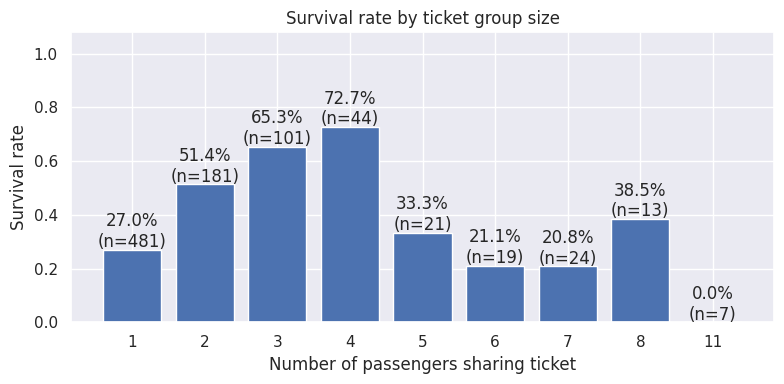

In [16]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

ticket_survival = (
    df_plot
    .groupby("TicketGroupSize")["Survived"]
    .agg(SurvivalRate="mean", Count="size")
    .reset_index()
    .sort_values("TicketGroupSize")
)

x = ticket_survival["TicketGroupSize"].astype(str)
y = ticket_survival["SurvivalRate"]

plt.figure(figsize=(8, 4))
plt.bar(x, y)

plt.title("Survival rate by ticket group size")
plt.xlabel("Number of passengers sharing ticket")
plt.ylabel("Survival rate")

for i, (xi, yi, n) in enumerate(zip(x, y, ticket_survival["Count"])):
    plt.text(
        i,
        yi + 0.01,
        f"{yi:.1%}\n(n={n})",
        ha="center"
    )

plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

Os resultados indicam que as taxas de sobrevivência variam entre diferentes tamanhos de grupos de bilhete, embora a relação seja menos suave do que a observada para `FamilySize`. Grupos menores de passageiros com o mesmo bilhete tendem a apresentar probabilidades de sobrevivência relativamente maiores, enquanto grupos maiores são menos frequentes e apresentam maior variabilidade devido ao número limitado de observações.

Em comparação com `FamilySize`, esse atributo captura um aspecto diferente dos agrupamentos de passageiros, provavelmente refletindo estruturas de reserva ou organização da viagem, em vez de relações familiares. Como resultado, `TicketGroupSize` fornece informações complementares que podem ajudar os modelos de aprendizado de máquina a identificar padrões adicionais que não são capturados apenas pelas conexões familiares.


# `AgeCategory` (a partir de `Age`)

A relação entre idade e sobrevivência provavelmente não é linear. Relatos históricos sugerem que crianças receberam prioridade durante a evacuação, enquanto os padrões de sobrevivência entre adultos e passageiros mais idosos podem apresentar comportamentos mais complexos.

Para capturar esses possíveis efeitos não lineares de forma mais eficiente, transformamos `Age` em uma variável categórica agrupando os passageiros em faixas etárias significativas. Isso permite que o modelo aprenda padrões relacionados à idade sem assumir uma relação estritamente linear.


In [17]:
# Create feature
bins = [-1, 12, 18, 35, 60, np.inf]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
df_full["AgeCategory"] = pd.cut(
    df_full["Age"],
    bins=bins,
    labels=labels
)

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "AgeCategory",
    "Type": "categorical",
    "Category": "engineered",
    "Source": "Age",
    "UsedInModel": False,
    "Description": "Binned representation of passenger age capturing non-linear survival patterns across age groups."
}

O atributo `AgeCategory` foi introduzido para capturar possíveis efeitos não lineares da idade sobre a sobrevivência. Embora essa transformação agrupe os passageiros em segmentos demográficos significativos, ainda é necessário verificar se esses grupos apresentam padrões distintos de sobrevivência.

Para avaliar isso, comparamos as taxas de sobrevivência entre as diferentes categorias de idade.


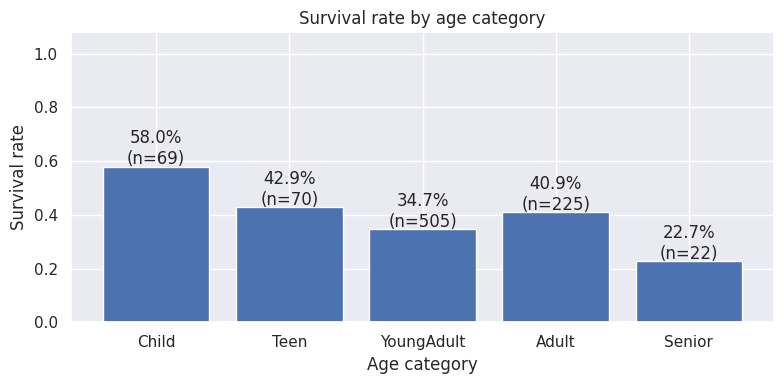

In [18]:
df_plot = df_full.loc[df_full["IsTrainSet"]].copy()

age_survival = (
    df_plot
    .groupby("AgeCategory", observed=False)["Survived"]
    .agg(SurvivalRate="mean", Count="size")
    .reindex(["Child", "Teen", "YoungAdult", "Adult", "Senior"])
    .reset_index()
)

x = age_survival["AgeCategory"].astype(str)
y = age_survival["SurvivalRate"]

plt.figure(figsize=(8, 4))
plt.bar(x, y)

plt.title("Survival rate by age category")
plt.xlabel("Age category")
plt.ylabel("Survival rate")

for i, (xi, yi, n) in enumerate(zip(x, y, age_survival["Count"])):
    plt.text(
        i,
        yi + 0.01,
        f"{yi:.1%}\n(n={n})",
        ha="center"
    )

plt.ylim(0, 1.08)
plt.tight_layout()
plt.show()

Os resultados mostram diferenças claras nas taxas de sobrevivência entre as categorias de idade. Crianças apresentam a maior probabilidade de sobrevivência, em concordância com as prioridades de evacuação, enquanto adultos e passageiros mais idosos apresentam taxas de sobrevivência comparativamente menores.

Esses padrões confirmam que a idade possui uma relação não linear com a sobrevivência e justificam a transformação de `Age` em uma representação categórica. Dessa forma, `AgeCategory` fornece uma codificação mais estruturada e adequada para os modelos dos efeitos relacionados à idade em comparação com a variável contínua original.


## Atributos transformados

Em contraste com os atributos construídos, que introduzem novas representações dos dados, os atributos transformados modificam a distribuição ou a escala de variáveis existentes sem alterar seu significado fundamental.

Essas transformações são particularmente úteis para reduzir assimetrias, estabilizar a variância e tornar os atributos mais adequados para algoritmos de aprendizado de máquina que são sensíveis à escala ou às características das distribuições dos dados.


### `SqrtAge` (a partir de `Age`)

Embora `Age` apresente uma assimetria menor do que `Fare`, sua distribuição ainda possui uma leve assimetria à direita devido à presença de um número relativamente menor de passageiros mais idosos.

A transformação pela raiz quadrada fornece uma correção suave dessa assimetria, preservando a interpretabilidade e mantendo a natureza contínua da variável.


In [19]:
# Create feature
df_full["SqrtAge"] = np.sqrt(df_full["Age"])

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "SqrtAge",
    "Type": "numerical",
    "Category": "transformed",
    "Source": "Age",
    "UsedInModel": False,
    "Description": "Square-root transformed version of Age to mildly reduce skewness while preserving interpretability."
}

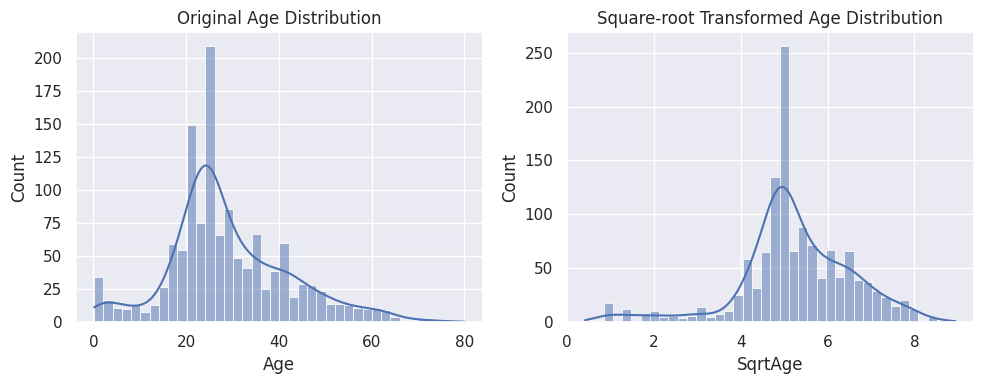

In [20]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_full["Age"], bins=40, kde=True)
plt.title("Original Age Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df_full["SqrtAge"], bins=40, kde=True)
plt.title("Square-root Transformed Age Distribution")

plt.tight_layout()
plt.show()

A transformação pela raiz quadrada comprime levemente os valores mais altos de `Age`, reduzindo a assimetria moderada da distribuição enquanto mantém a estrutura geral dos dados.

Diferentemente de transformações mais agressivas, como o logaritmo, essa abordagem preserva a interpretabilidade e garante que o atributo permaneça em uma escala contínua adequada para a maioria dos modelos de aprendizado de máquina.


### `LogFare` (a partir de `Fare`)

O atributo `Fare` apresenta uma distribuição altamente assimétrica, com um pequeno número de passageiros pagando valores significativamente maiores pelas passagens. Esses valores extremos podem influenciar de forma desproporcional alguns modelos de aprendizado de máquina.

Para reduzir esse efeito, aplicamos uma transformação logarítmica com o objetivo de comprimir a faixa de valores e reduzir a assimetria, preservando ao mesmo tempo a ordem relativa das observações.


In [21]:
# Create feature
df_full["LogFare"] = np.log1p(df_full["Fare"])

# Register feature in df_features
df_features.loc[len(df_features)] = {
    "Name": "LogFare",
    "Type": "numerical",
    "Category": "transformed",
    "Source": "Fare",
    "UsedInModel": False,
    "Description": "Log-transformed version of Fare to reduce right skewness and compress extreme values."
}

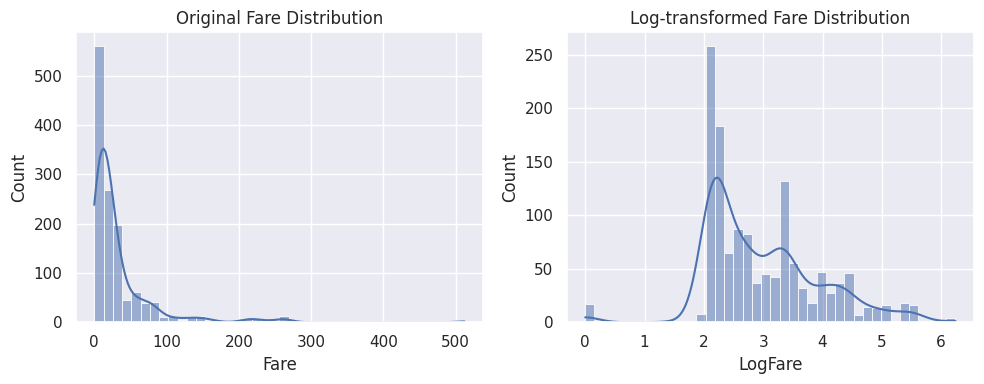

In [22]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_full["Fare"], bins=40, kde=True)
plt.title("Original Fare Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df_full["LogFare"], bins=40, kde=True)
plt.title("Log-transformed Fare Distribution")

plt.tight_layout()
plt.show()

A transformação logarítmica reduz significativamente a assimetria à direita da distribuição de `Fare`, comprimindo os valores extremos enquanto preserva as diferenças relativas entre tarifas menores e intermediárias.

Isso resulta em uma representação mais equilibrada do atributo, geralmente mais adequada para modelos de aprendizado de máquina sensíveis à escala e à presença de valores extremos.


## Atributos codificados

Após a engenharia de atributos e as transformações aplicadas, algumas variáveis permanecem em formato categórico. A maioria dos algoritmos de aprendizado de máquina requer entradas numéricas, portanto esses atributos precisam ser convertidos para representações adequadas, preservando seu conteúdo informativo.

Nesta seção, codificamos os atributos categóricos selecionados em formato numérico. O objetivo é tornar essas variáveis diretamente utilizáveis pelos modelos de aprendizado de máquina sem introduzir relações ordinais artificiais ou perder o significado estrutural dos dados.

A etapa de codificação é restrita aos atributos que representam estruturas categóricas. Variáveis contínuas e baseadas em contagem que já possuem informações de magnitude relevantes, como `TicketGroupSize`, são mantidas em sua forma original para preservar sua interpretabilidade e sinal preditivo.


### `Sex`

O atributo `Sex` apresentou uma das relações mais fortes com a sobrevivência durante a análise exploratória, com passageiros do sexo feminino apresentando taxas de sobrevivência significativamente maiores do que passageiros do sexo masculino.

Para tornar essa informação utilizável pelos modelos de aprendizado de máquina, convertemos a variável categórica em uma representação numérica binária, preservando todo o seu conteúdo informativo.


In [23]:
# Encode Sex as binary feature
df_full["Sex"] = df_full["Sex"].map({"male": 0, "female": 1})

# Register encoded feature in df_features
df_features.loc[
    df_features["Name"] == "Sex",
    ["Type", "Category", "Description"]
] = [
    "indicator",
    "encoded",
    "Binary encoding of passenger sex (0 = male, 1 = female).",
]

### `Embarked`

O atributo `Embarked` indica o porto onde cada passageiro embarcou no Titanic. Embora essa variável não determine diretamente a sobrevivência, a análise exploratória sugeriu diferenças nas taxas de sobrevivência entre os pontos de embarque, provavelmente refletindo diferenças na composição dos passageiros.

Para incorporar essa informação aos modelos de aprendizado de máquina, aplicamos a codificação one-hot, garantindo que nenhuma ordem artificial seja imposta entre as categorias.


In [24]:
# One-hot encode Embarked
embarked_dummies = pd.get_dummies(df_full["Embarked"], prefix="Embarked")

df_full = pd.concat([df_full, embarked_dummies], axis=1)

# Register encoded features
for col in embarked_dummies.columns:
    df_features.loc[len(df_features)] = {
        "Name": col,
        "Type": "indicator",
        "Category": "encoded",
        "Source": "Embarked",
        "UsedInModel": True,
        "Description": "One-hot encoding of embarkation port."
    }

### `TitleGrouped`

O atributo `TitleGrouped` captura o status social e os papéis demográficos dos passageiros em uma forma categórica compacta, derivada de `Name`. Durante a análise exploratória, essa variável apresentou uma forte separação nas taxas de sobrevivência, especialmente entre títulos comuns como `Mr`, `Mrs`, `Miss`, `Master` e a categoria agrupada `Rare`.

Para incorporar esse sinal social estruturado aos modelos de aprendizado de máquina, aplicamos a codificação one-hot, garantindo que cada categoria de título seja representada sem impor qualquer relação ordinal entre elas.


In [25]:
# One-hot encode TitleGrouped
title_dummies = pd.get_dummies(df_full["TitleGrouped"], prefix="Title")

df_full = pd.concat([df_full, title_dummies], axis=1)

# Register encoded features
for col in title_dummies.columns:
    df_features.loc[len(df_features)] = {
        "Name": col,
        "Type": "indicator",
        "Category": "encoded",
        "Source": "TitleGrouped",
        "UsedInModel": True,
        "Description": "One-hot encoding of grouped passenger titles capturing social and demographic status."
    }

### `AgeCategory`

O atributo `AgeCategory` captura segmentos de idade significativos com padrões distintos de sobrevivência. No entanto, por ser uma variável categórica, ela não pode ser utilizada diretamente pela maioria dos modelos de aprendizado de máquina.

Para incorporar essa informação ao pipeline de modelagem sem impor relações ordinais artificiais, aplicamos a codificação one-hot, representando cada faixa etária como um atributo binário separado.


In [26]:
# One-hot encode AgeCategory
age_dummies = pd.get_dummies(df_full["AgeCategory"], prefix="Age")

df_full = pd.concat([df_full, age_dummies], axis=1)

# Register encoded features
for col in age_dummies.columns:
    df_features.loc[len(df_features)] = {
        "Name": col,
        "Type": "indicator",
        "Category": "encoded",
        "Source": "AgeCategory",
        "UsedInModel": True,
        "Description": "One-hot encoded age category derived from Age."
    }

### `Pclass`

O atributo `Pclass` representa o status socioeconômico dos passageiros, apresentando uma estrutura ordinal clara (`1ª classe` > `2ª classe` > `3ª classe`). Durante a análise exploratória, esse atributo apresentou uma forte associação com a sobrevivência, com passageiros da primeira classe apresentando taxas de sobrevivência significativamente maiores.

Para incorporar esse atributo aos modelos de aprendizado de máquina, preservamos sua natureza ordinal por meio de uma codificação numérica direta, permitindo que os modelos explorem sua ordenação inerente.

Diferentemente dos demais atributos codificados nesta seção, `Pclass` já está representado numericamente no conjunto de dados original. No entanto, seus valores não são inteiros arbitrários. Eles representam uma ordenação natural associada ao status socioeconômico dos passageiros, com a primeira classe representando o maior nível socioeconômico e a terceira classe o menor.

Por esse motivo, nenhuma codificação adicional é necessária. Simplesmente mantemos `Pclass` em sua forma numérica original, permitindo que os modelos de aprendizado de máquina explorem diretamente sua estrutura ordinal.


In [27]:
# Ensure correct type
df_full["Pclass"] = df_full["Pclass"].astype(int)

# Register encoded feature in df_features
df_features.loc[
    df_features["Name"] == "Pclass",
    ["Type", "Category", "UsedInModel"]
] = ["numerical", "original", True]

Embora `Pclass` apareça na seção de atributos codificados, ele difere dos atributos anteriores pelo fato de que nenhuma transformação é aplicada. Em vez de converter uma variável categórica em uma representação numérica, simplesmente preservamos um atributo numérico existente cuja estrutura ordinal já possui significado para os modelos de aprendizado de máquina.


## Conjunto final de atributos

Neste estágio, todas as etapas de engenharia de atributos, transformações e codificação foram concluídas. O conjunto de dados agora contém tanto as variáveis originais quanto os novos atributos criados, alguns dos quais representam diferentes formas de visualizar as mesmas informações subjacentes.

Para evitar redundâncias durante o treinamento dos modelos, utilizamos o registro de atributos (`df_features`) para identificar o subconjunto de variáveis que será incluído nos modelos de aprendizado de máquina. A coluna `UsedInModel` registra essa decisão, fornecendo uma especificação transparente e reprodutível do conjunto final de atributos.


In [28]:
# Original features
df_features.loc[
    df_features["Name"].isin([
        "Pclass",
        "Sex",
        "Age",
        "Fare",
        "SibSp",
        "Parch",
    ]),
    "UsedInModel"
] = True

# Engineered features
df_features.loc[
    df_features["Name"].isin([
        "FamilySize",
        "IsAlone",
        "TicketGroupSize",
    ]),
    "UsedInModel"
] = True

# Transformed features
df_features.loc[
    df_features["Name"].isin([
        "LogFare",
        "SqrtAge",
    ]),
    "UsedInModel"
] = True

# Encoded features
df_features.loc[
    df_features["Name"].isin([
        "Embarked_C",
        "Embarked_Q",
        "Embarked_S",
        "Title_Master",
        "Title_Miss",
        "Title_Mr",
        "Title_Mrs",
        "Title_Rare",
        "Age_Child",
        "Age_Teen",
        "Age_YoungAdult",
        "Age_Adult",
        "Age_Senior",
    ]),
    "UsedInModel"
] = True

In [29]:
# Features not used in the modeling stage
df_features.loc[~df_features["UsedInModel"]]

,Name,Type,Category,Source,Description,UsedInModel
1,Name,categorical,original,Name,Passenger's full name.,False
6,Ticket,categorical,original,Ticket,Ticket number.,False
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu...",False
9,Title,categorical,extracted,Name,Honorific title extracted from the passenger's...,False
10,TitleGrouped,categorical,engineered,Title,Passenger title with infrequent categories gro...,False
14,AgeCategory,categorical,engineered,Age,Binned representation of passenger age capturi...,False


In [30]:
# Features that will be used in the modeling stage
df_features.loc[df_features["UsedInModel"]]

,Name,Type,Category,Source,Description,UsedInModel
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec...",True
2,Sex,indicator,encoded,Sex,"Binary encoding of passenger sex (0 = male, 1 ...",True
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...,True
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...,True
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...,True
7,Fare,numerical,original,Fare,Passenger fare.,True
11,FamilySize,numerical,engineered,"SibSp, Parch","Total number of family members aboard, includi...",True
12,IsAlone,indicator,engineered,FamilySize,Binary indicator of whether the passenger was ...,True
13,TicketGroupSize,numerical,engineered,Ticket,"Number of passengers sharing the same ticket, ...",True
15,SqrtAge,numerical,transformed,Age,Square-root transformed version of Age to mild...,True


## Salvando o conjunto de dados processado

Neste estágio, a engenharia de atributos, as transformações e a codificação foram concluídas. O conjunto de dados resultante contém as variáveis originais juntamente com os atributos construídos e transformados que serão utilizados ao longo da etapa de modelagem. O registro de atributos (`df_features`) também documenta a origem, o tipo e o status de uso no modelo de cada atributo, fornecendo uma especificação transparente do conjunto final de variáveis.

Para evitar a repetição dessas etapas de pré-processamento nos notebooks seguintes, salvamos em disco tanto o conjunto de dados processado quanto o registro de atributos atualizado.


In [31]:
# Save dataframes in parquet format to preserve data types
df_full.to_parquet(
    "../data/processed/02_data.parquet",
    index=False
)

df_features.to_parquet(
    "../data/processed/02_features.parquet",
    index=False
)

## Próximos passos

O conjunto de dados está agora totalmente preparado para o aprendizado de máquina. No [próximo notebook](03_modeling_and_evaluation.ipynb), construiremos o conjunto de dados para modelagem, dividiremos os dados em conjuntos de treinamento e validação, treinaremos diferentes algoritmos de classificação e compararemos seus desempenhos preditivos. Também avaliaremos a importância dos atributos e o comportamento dos modelos para compreender melhor os fatores que contribuem para a sobrevivência dos passageiros.
